# Deep CFR: Confirm Positive-Regret Weighting

This is a focused paired-seed experiment comparing the existing masked-MSE advantage loss against positive-regret-weighted MSE with `beta=0.5`.

Each run receives the same measured training-time budget. Exact best-response evaluation, validation, and exact dense averaging are outside that budget. The primary metric is **exact generated-average exploitability**, because it evaluates the strategy sequence independently of the learned average-strategy network.

In [1]:
import gc
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'liars_poker').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from liars_poker.algo.deep_cfr import DeepCFRTrainer
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.core import GameSpec
from liars_poker.training.deep_cfr import deep_cfr_timed_loop

In [7]:
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=2,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)

training_seconds = 12 * 60
seeds = (7, 17, 27)
traversals_per_player = 50
eval_every = 10

common_kwargs = {
    'hidden_sizes': (64, 64),
    'advantage_buffer_capacity': 100_000,
    'strategy_buffer_capacity': 100_000,
    'batch_size': 128,
    'advantage_train_steps': 100,
    'strategy_train_steps': 100,
    'learning_rate': 1e-3,
    'strategy_weighting': 'linear',
    'highest_regret_fallback': True,
    'alternating_updates': True,
    'retrain_advantage_from_scratch': False,
    'validation_fraction': 0.05,
    'validation_buffer_capacity': 10_000,
}

spec.to_short_str(), training_seconds, seeds

('r4_s4_h2_hpt_ss', 720, (7, 17, 27))

## Loss implementation

`positive_beta=0` exactly recovers the repository's existing masked MSE. Positive targets receive action weight `1 + beta`; other legal targets receive weight `1`. Strategy-network training is unchanged.

In [8]:
class PositiveWeightedDeepCFRTrainer(DeepCFRTrainer):
    def __init__(self, spec, *, positive_beta=0.0, **kwargs):
        super().__init__(spec, **kwargs)
        self.positive_beta = float(positive_beta)

    def _train_model(self, model, optimizer, buffer, steps, *, strategy_loss):
        if strategy_loss or self.positive_beta == 0.0:
            return super()._train_model(
                model,
                optimizer,
                buffer,
                steps,
                strategy_loss=strategy_loss,
            )
        if buffer.size == 0 or steps <= 0:
            return 0.0

        model.train()
        total_loss = 0.0
        for _ in range(steps):
            features, targets, masks, weights = buffer.sample(self.batch_size, self.rng)
            x = torch.from_numpy(features).to(self.device)
            y = torch.from_numpy(targets).to(self.device)
            mask = torch.from_numpy(masks).to(self.device)
            sample_weight = torch.from_numpy(weights).to(self.device)
            sample_weight = sample_weight / sample_weight.mean().clamp_min(1e-8)

            pred = model(x)
            action_weight = mask.float() * (1.0 + self.positive_beta * (y > 0.0).float())
            per_sample = ((pred - y).square() * action_weight).sum(dim=1) / action_weight.sum(dim=1).clamp_min(1.0)
            loss = (per_sample * sample_weight).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())

        model.eval()
        return total_loss / steps


variants = {
    'masked MSE': 0.0,
    'positive beta=0.5': 0.5,
}

## Run paired seeds

Runs are paired by seed. Large trainers and buffers are released after each run; only logs are retained.

In [9]:
runs = []

for seed in seeds:
    for label, beta in variants.items():
        print(f'\n=== seed={seed}; {label} ===')
        trainer = PositiveWeightedDeepCFRTrainer(
            spec,
            positive_beta=beta,
            seed=seed,
            **common_kwargs,
        )
        exact_averager = ExactDenseStrategyAverager(spec)
        _, logs, trainer = deep_cfr_timed_loop(
            spec,
            training_seconds=training_seconds,
            trainer=trainer,
            traversals_per_player=traversals_per_player,
            eval_every=eval_every,
            exact_averager=exact_averager,
            debug=True,
        )
        runs.append({
            'seed': seed,
            'variant': label,
            'logs': logs,
            'iterations': trainer.iteration,
        })
        del trainer, exact_averager
        gc.collect()



=== seed=7; masked MSE ===
[deep-cfr] iter=1 training_budget=2.23/720.00s traverse=0.53s fit=1.70s
[deep-cfr] iter=2 training_budget=7.75/720.00s traverse=3.70s fit=1.81s
[deep-cfr] iter=3 training_budget=11.00/720.00s traverse=1.54s fit=1.71s
[deep-cfr] iter=4 training_budget=14.43/720.00s traverse=1.76s fit=1.67s
[deep-cfr] iter=5 training_budget=17.77/720.00s traverse=1.63s fit=1.72s
[deep-cfr] iter=6 training_budget=20.83/720.00s traverse=1.37s fit=1.68s
[deep-cfr] iter=7 training_budget=24.18/720.00s traverse=1.66s fit=1.69s
[deep-cfr] iter=8 training_budget=27.67/720.00s traverse=1.74s fit=1.76s
[deep-cfr] iter=9 training_budget=31.18/720.00s traverse=1.89s fit=1.63s
[deep-cfr] iter=10 training_budget=34.76/720.00s traverse=1.88s fit=1.70s
[deep-cfr] iter=11 training_budget=38.52/720.00s traverse=2.07s fit=1.70s
[deep-cfr] iter=12 training_budget=42.23/720.00s traverse=2.07s fit=1.64s
[deep-cfr] iter=13 training_budget=45.69/720.00s traverse=1.79s fit=1.66s
[deep-cfr] iter=14 tr

In [10]:
def evaluation_seconds(run):
    elapsed_by_iter = {
        record['iteration']: record['elapsed_s']
        for record in run['logs']['training_series']
    }
    return np.asarray([
        elapsed_by_iter[point['iter']]
        for point in run['logs']['exploitability_series']
    ])


def exploitability_values(run, key):
    return np.asarray([
        2 * point[key] - 1
        for point in run['logs']['exploitability_series']
    ])


def training_validation_series(run, family, key):
    records = [record for record in run['logs']['training_series'] if 'validation' in record]
    x = np.asarray([record['elapsed_s'] for record in records])
    y = np.asarray([
        np.mean([player[key] for player in record['validation'][family] if key in player])
        for record in records
    ])
    return x, y


def interpolate_runs(selected_runs, key, points=100):
    stop = min(evaluation_seconds(run)[-1] for run in selected_runs)
    grid = np.linspace(0.0, stop, points)
    values = np.asarray([
        np.interp(grid, evaluation_seconds(run), exploitability_values(run, key))
        for run in selected_runs
    ])
    return grid, values

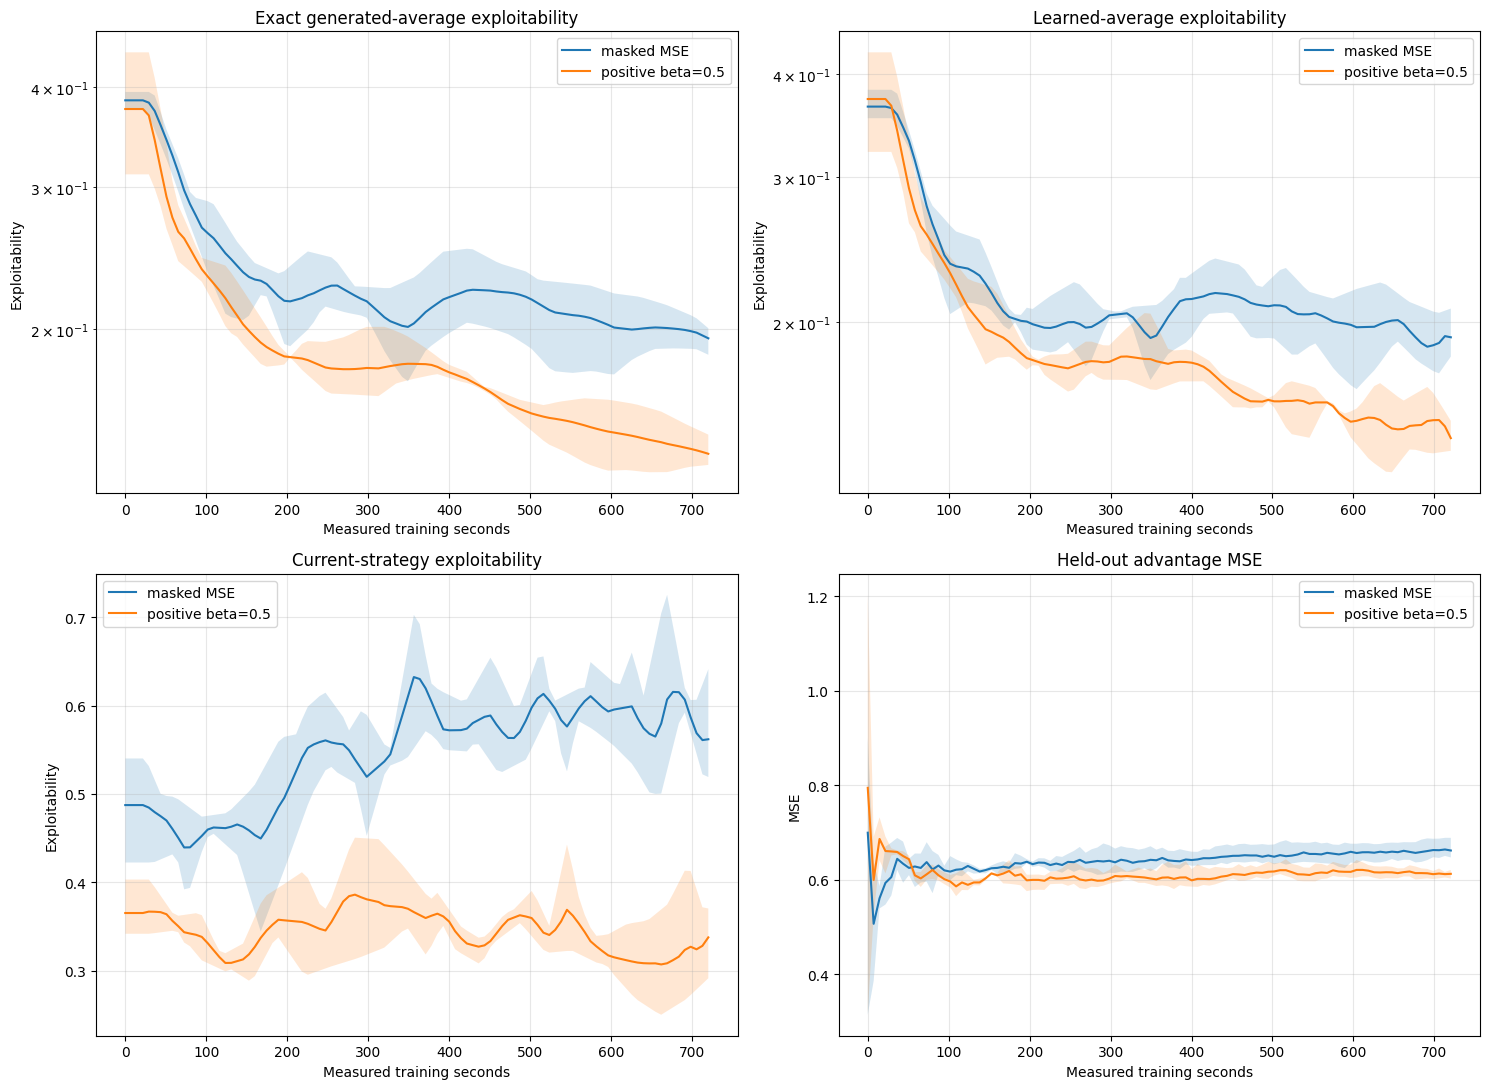

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for label in variants:
    selected = [run for run in runs if run['variant'] == label]
    for ax, key in zip(
        axes.flat[:3],
        ('exact_average_predicted_avg', 'predicted_avg', 'current_predicted_avg'),
    ):
        x, values = interpolate_runs(selected, key)
        ax.plot(x, values.mean(axis=0), label=label)
        ax.fill_between(x, values.min(axis=0), values.max(axis=0), alpha=0.18)

    validation_runs = []
    for run in selected:
        x, y = training_validation_series(run, 'advantage', 'mse')
        validation_runs.append((x, y))
    stop = min(x[-1] for x, _ in validation_runs)
    grid = np.linspace(0.0, stop, 100)
    values = np.asarray([np.interp(grid, x, y) for x, y in validation_runs])
    axes[1, 1].plot(grid, values.mean(axis=0), label=label)
    axes[1, 1].fill_between(grid, values.min(axis=0), values.max(axis=0), alpha=0.18)

plot_specs = [
    ('Exact generated-average exploitability', 'Exploitability', True),
    ('Learned-average exploitability', 'Exploitability', True),
    ('Current-strategy exploitability', 'Exploitability', False),
    ('Held-out advantage MSE', 'MSE', False),
]
for ax, (title, ylabel, log_y) in zip(axes.flat, plot_specs):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
fig.tight_layout();


## Paired-seed summary

The normalized area under the exact-average exploitability curve rewards fast, stable convergence over the full measured training budget. Lower is better.

In [12]:
summary_rows = []
for run in runs:
    exact = exploitability_values(run, 'exact_average_predicted_avg')
    learned = exploitability_values(run, 'predicted_avg')
    current = exploitability_values(run, 'current_predicted_avg')
    seconds = evaluation_seconds(run)
    validation_x, validation_mse = training_validation_series(run, 'advantage', 'mse')
    summary_rows.append({
        'seed': run['seed'],
        'variant': run['variant'],
        'iterations completed': run['iterations'],
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'exact-average normalized AUC': float(np.trapezoid(exact, seconds) / (seconds[-1] - seconds[0])),
        'final learned-average exploitability': learned[-1],
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'final held-out advantage MSE': validation_mse[-1],
    })

summary_df = pd.DataFrame(summary_rows).set_index(['seed', 'variant']).sort_index()
display(summary_df.style.format(precision=6))

paired = summary_df.reset_index().pivot(index='seed', columns='variant')
paired_differences = pd.DataFrame({
    metric: paired[metric]['positive beta=0.5'] - paired[metric]['masked MSE']
    for metric in (
        'final exact-average exploitability',
        'best exact-average exploitability',
        'exact-average normalized AUC',
        'final learned-average exploitability',
        'final held-out advantage MSE',
    )
})
paired_differences.index.name = 'seed; beta=0.5 minus masked MSE'
display(paired_differences.style.format(precision=6).background_gradient(cmap='RdYlGn_r', axis=None))

aggregate = summary_df.groupby('variant').agg(['mean', 'std'])
aggregate.style.format(precision=6)

,final exact-average exploitability,best exact-average exploitability,exact-average normalized AUC,final learned-average exploitability,final held-out advantage MSE
seed; beta=0.5 minus masked MSE,,,,,
7,-0.050382,-0.040786,-0.046278,-0.031438,-0.045661
17,-0.063174,-0.063174,-0.058829,-0.068075,-0.034797
27,-0.050241,-0.038381,-0.026539,-0.042074,-0.074454
